# LoRa Interference and Receiver Impairments

Notebook 5 calculated propagation and installation effects. This notebook starts at the receiver input and asks a different question: what happens when the desired LoRa chirp shares the receiver with other signals or imperfect hardware?

```text
desired LoRa + other LoRa/Wi-Fi residue + receiver noise -> oscillator error -> dechirp -> FFT decision
```

The experiments separate four mechanisms:

1. co-SF and cross-SF LoRa collisions;
2. residual carrier-frequency offset after synchronization;
3. effective in-band Wi-Fi leakage after the LoRa receiver filter; and
4. measured motor/ESC receiver desensitization represented as a noise-floor penalty.

This remains a symbol-level teaching model. It does not yet implement preamble acquisition, packet capture, FEC, CRC, retransmissions, or a bit-exact commercial LoRa receiver.


## 1. Desired signal, interference, and noise

We write one received symbol as

$$y[n]=s[n]+\sqrt{P_i}e^{j\phi}i[n]+w[n],$$

where $s[n]$ is the unit-power desired chirp, $i[n]$ is a unit-power interferer, and $w[n]$ is complex AWGN. The signal-to-interference ratio is

$$SIR_{dB}=10\log_{10}\frac{P_s}{P_i}.$$

Positive SIR means the desired signal is stronger. SNR is referenced to desired-signal power, so increasing interference does not accidentally increase the simulated thermal-noise power.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

FC_HZ = 2.44e9
BW_HZ = 812_500.0
DESIRED_SF = 9
SAMPLE_SNR_DB = -12.0

def reference_upchirp(sf):
    m = 1 << sf
    n = np.arange(m, dtype=float)
    return np.exp(1j * 2 * np.pi * (n**2 / (2 * m) - n / 2))

def lora_symbol(symbol, sf):
    m = 1 << sf
    if not 0 <= int(symbol) < m:
        raise ValueError(f"symbol must be in [0, {m})")
    return np.roll(reference_upchirp(sf), -int(symbol))

def detect_symbol(samples, sf):
    spectrum = np.fft.fft(samples * np.conj(reference_upchirp(sf)))
    return int(np.argmax(np.abs(spectrum))), spectrum

def unit_power(samples):
    return samples / np.sqrt(np.mean(np.abs(samples)**2))

def add_awgn(samples, snr_db, rng, desired_power=1.0):
    noise_power = desired_power / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (rng.standard_normal(samples.size) + 1j * rng.standard_normal(samples.size))
    return samples + noise

def mix_at_sir(desired, interferer, sir_db, phase_rad=0.0):
    amplitude = 10 ** (-sir_db / 20)
    return unit_power(desired) + amplitude * np.exp(1j * phase_rad) * unit_power(interferer)

for sf in (7, 9, 12):
    for symbol in (0, 1, (1 << sf) - 1):
        detected, _ = detect_symbol(lora_symbol(symbol, sf), sf)
        assert detected == symbol
print("Ideal SF7, SF9, and SF12 round-trip checks passed.")


Ideal SF7, SF9, and SF12 round-trip checks passed.


## 2. Co-SF versus cross-SF LoRa collisions

A synchronized co-SF interferer dechirps into another concentrated FFT peak. If that peak is stronger than the desired peak, the detector normally selects the wrong symbol.

A different-SF interferer does not dechirp into one stationary tone at the desired receiver. Its energy spreads over many bins. This is useful separation, but it is not perfect orthogonality: timing offsets, frequency errors, unequal powers, preambles, and receiver implementation all matter.


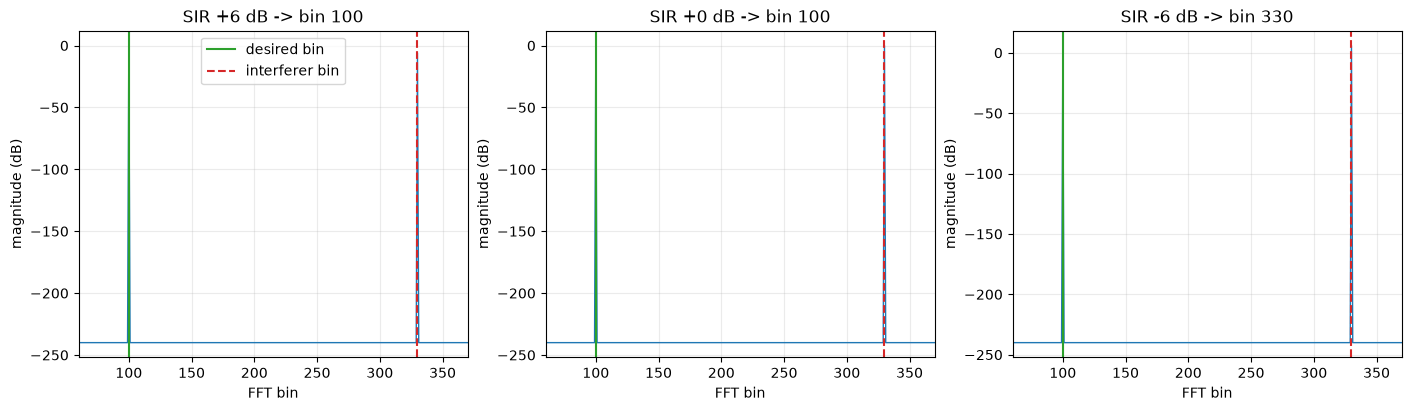

In [2]:
rng = np.random.default_rng(2026)
desired_symbol = 100
interfering_symbol = 330
desired = lora_symbol(desired_symbol, DESIRED_SF)
co_sf = lora_symbol(interfering_symbol, DESIRED_SF)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, sir_db in zip(axes, (6, 0, -6)):
    received = mix_at_sir(desired, co_sf, sir_db, phase_rad=0.7)
    detected, spectrum = detect_symbol(received, DESIRED_SF)
    magnitude_db = 20 * np.log10(np.maximum(np.abs(spectrum) / len(spectrum), 1e-12))
    ax.plot(magnitude_db, linewidth=1)
    ax.axvline(desired_symbol, color="C2", label="desired bin")
    ax.axvline(interfering_symbol, color="C3", linestyle="--", label="interferer bin")
    ax.set(title=f"SIR {sir_db:+d} dB -> bin {detected}", xlabel="FFT bin", ylabel="magnitude (dB)", xlim=(60, 370))
axes[0].legend()
plt.show()


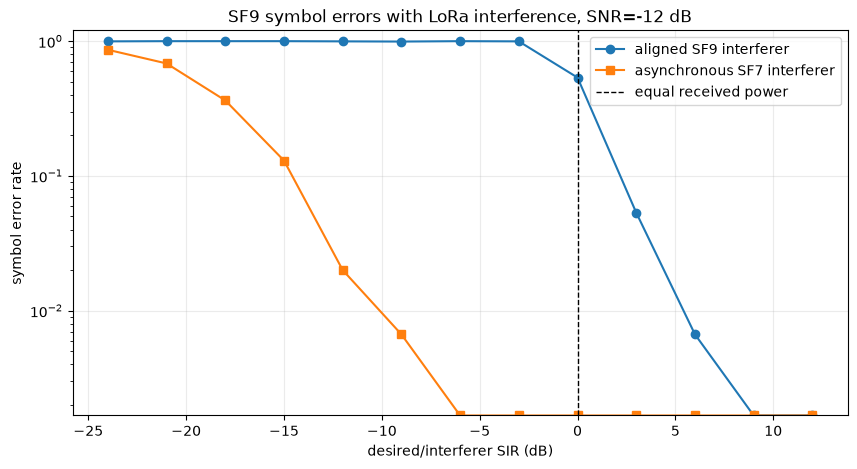

In [3]:
def collision_interferer(target_sf, interferer_sf, rng):
    target_length = 1 << target_sf
    interferer_length = 1 << interferer_sf
    if interferer_sf == target_sf:
        return lora_symbol(rng.integers(interferer_length), interferer_sf)

    offset = int(rng.integers(interferer_length))
    symbol_count = int(np.ceil((target_length + offset) / interferer_length))
    waveform = np.concatenate([
        lora_symbol(rng.integers(interferer_length), interferer_sf)
        for _ in range(symbol_count)
    ])
    return waveform[offset:offset + target_length]

def simulate_collision_ser(interferer_sf, sir_values_db, trials=300):
    rng = np.random.default_rng(1000 + interferer_sf)
    m = 1 << DESIRED_SF
    output = []
    for sir_db in sir_values_db:
        errors = 0
        for _ in range(trials):
            sent = int(rng.integers(m))
            desired = lora_symbol(sent, DESIRED_SF)
            interferer = collision_interferer(DESIRED_SF, interferer_sf, rng)
            mixed = mix_at_sir(desired, interferer, sir_db, rng.uniform(0, 2 * np.pi))
            received = add_awgn(mixed, SAMPLE_SNR_DB, rng)
            detected, _ = detect_symbol(received, DESIRED_SF)
            errors += detected != sent
        output.append(errors / trials)
    return np.asarray(output)

SIR_DB = np.arange(-24, 13, 3)
co_sf_ser = simulate_collision_ser(9, SIR_DB)
cross_sf_ser = simulate_collision_ser(7, SIR_DB)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(SIR_DB, np.maximum(co_sf_ser, 1 / 600), marker="o", label="aligned SF9 interferer")
ax.semilogy(SIR_DB, np.maximum(cross_sf_ser, 1 / 600), marker="s", label="asynchronous SF7 interferer")
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="equal received power")
ax.set(title=f"SF9 symbol errors with LoRa interference, SNR={SAMPLE_SNR_DB:g} dB", xlabel="desired/interferer SIR (dB)", ylabel="symbol error rate", ylim=(1 / 600, 1.2))
ax.legend()
plt.show()

assert co_sf_ser[0] > 0.9
assert cross_sf_ser[np.where(SIR_DB == -12)[0][0]] < co_sf_ser[np.where(SIR_DB == -12)[0][0]]


The comparison is intentionally controlled, not a universal capture curve. The co-SF signal is symbol-aligned, while the SF7 signal begins at a random offset and several SF7 symbols overlap one SF9 symbol. Packet preamble acquisition and capture can change the result substantially.


## 3. Residual oscillator error

A carrier-frequency offset $\Delta f$ rotates every sample:

$$y[n]=x[n]e^{j2\pi\Delta f n/F_s}.$$

After dechirping, this moves the FFT tone by approximately

$$\Delta k=\frac{\Delta f}{BW/2^{SF}}.$$

Raw crystal error may be several parts per million, so practical receivers estimate frequency offset from the preamble. The experiment below concerns the **residual** error after that synchronization step.


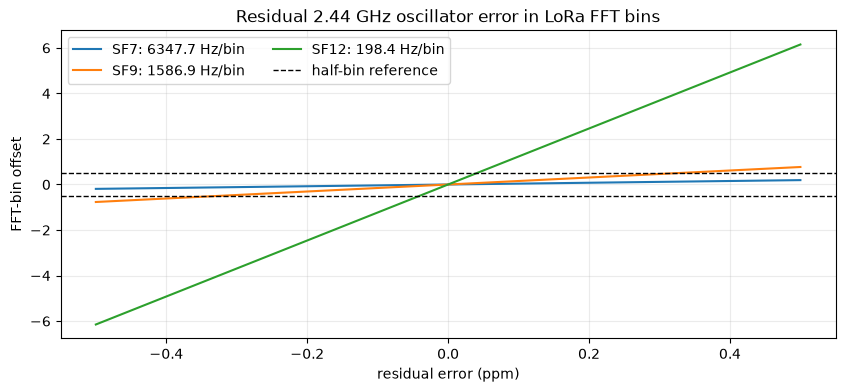

At 2.44 GHz, 0.1 ppm is 244 Hz.


In [4]:
residual_ppm = np.linspace(-0.5, 0.5, 101)
residual_cfo_hz = residual_ppm * FC_HZ / 1e6

fig, ax = plt.subplots(figsize=(10, 4))
for sf in (7, 9, 12):
    bin_spacing_hz = BW_HZ / (1 << sf)
    ax.plot(residual_ppm, residual_cfo_hz / bin_spacing_hz, label=f"SF{sf}: {bin_spacing_hz:.1f} Hz/bin")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.axhline(-0.5, color="black", linestyle="--", linewidth=1, label="half-bin reference")
ax.set(title="Residual 2.44 GHz oscillator error in LoRa FFT bins", xlabel="residual error (ppm)", ylabel="FFT-bin offset")
ax.legend(ncol=2)
plt.show()

print(f"At 2.44 GHz, 0.1 ppm is {0.1 * FC_HZ / 1e6:.0f} Hz.")


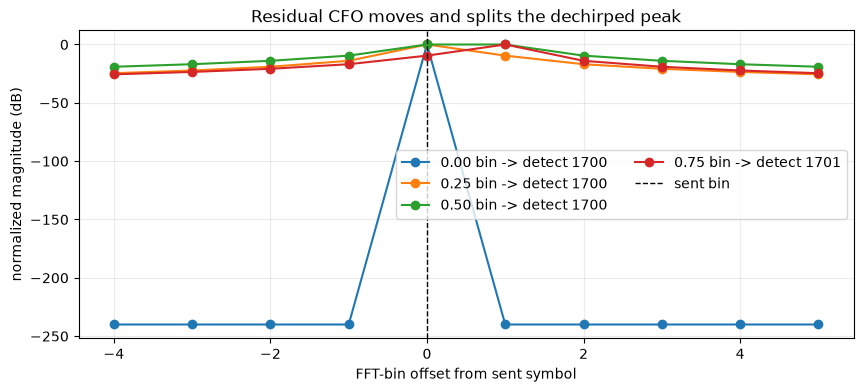

In [5]:
def apply_frequency_offset(samples, offset_hz, sample_rate_hz=BW_HZ):
    n = np.arange(samples.size)
    return samples * np.exp(1j * 2 * np.pi * offset_hz * n / sample_rate_hz)

sf = 12
symbol = 1700
bin_spacing_hz = BW_HZ / (1 << sf)
fig, ax = plt.subplots(figsize=(10, 4))
for offset_bins in (0, 0.25, 0.50, 0.75):
    received = apply_frequency_offset(lora_symbol(symbol, sf), offset_bins * bin_spacing_hz)
    detected, spectrum = detect_symbol(received, sf)
    magnitude = np.abs(spectrum)
    neighborhood = np.arange(symbol - 4, symbol + 6)
    magnitude_db = 20 * np.log10(np.maximum(magnitude[neighborhood] / magnitude.max(), 1e-12))
    ax.plot(neighborhood - symbol, magnitude_db, marker="o", label=f"{offset_bins:.2f} bin -> detect {detected}")
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="sent bin")
ax.set(title="Residual CFO moves and splits the dechirped peak", xlabel="FFT-bin offset from sent symbol", ylabel="normalized magnitude (dB)")
ax.legend(ncol=2)
plt.show()


## 4. Effective Wi-Fi leakage inside the LoRa channel

A 20 MHz Wi-Fi signal cannot be represented faithfully at the LoRa sample rate $F_s=BW=812.5$ kHz. More importantly, the LoRa detector does not receive all 20 MHz: its RF/IF channel filter rejects most out-of-band energy.

We therefore model the **residual in-band waveform after that filter**. The teaching surrogate uses three time-varying QPSK subcarriers spaced by 312.5 kHz, matching the legacy 20 MHz Wi-Fi OFDM subcarrier spacing. It is not a standards-compliant 802.11 packet. Its SIR must represent power measured after the LoRa front end.


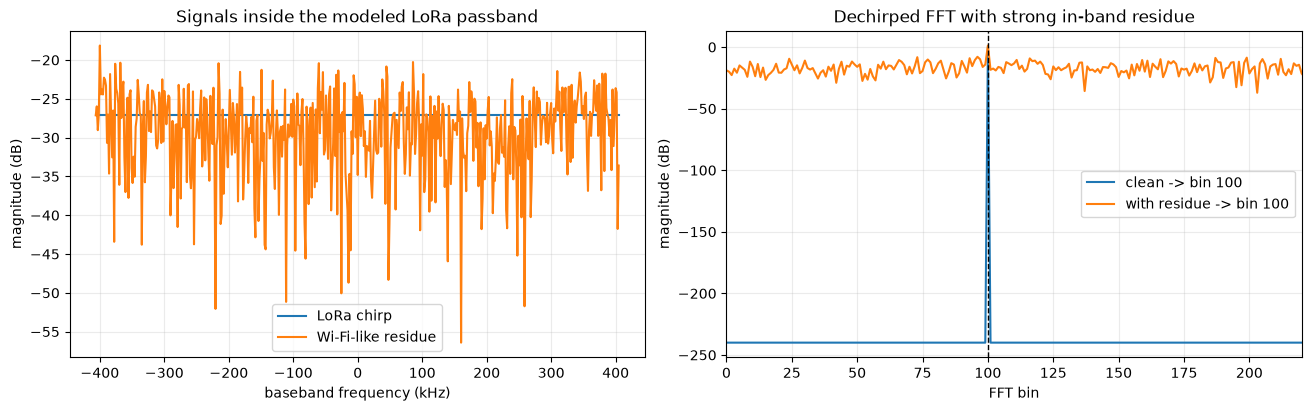

In [6]:
def wifi_like_inband_residue(num_samples, rng):
    samples_per_ofdm_symbol = max(1, round(4e-6 * BW_HZ))
    num_symbols = int(np.ceil(num_samples / samples_per_ofdm_symbol))
    subcarrier_hz = np.array([-312_500.0, 0.0, 312_500.0])
    qpsk = (
        2 * rng.integers(0, 2, (len(subcarrier_hz), num_symbols)) - 1
        + 1j * (2 * rng.integers(0, 2, (len(subcarrier_hz), num_symbols)) - 1)
    ) / np.sqrt(2)
    qpsk = np.repeat(qpsk, samples_per_ofdm_symbol, axis=1)[:, :num_samples]
    time_s = np.arange(num_samples) / BW_HZ
    tones = np.exp(1j * 2 * np.pi * subcarrier_hz[:, None] * time_s)
    return unit_power(np.sum(qpsk * tones, axis=0))

rng = np.random.default_rng(88)
m = 1 << DESIRED_SF
desired_symbol = 100
desired = lora_symbol(desired_symbol, DESIRED_SF)
wifi_residue = wifi_like_inband_residue(m, rng)
received = mix_at_sir(desired, wifi_residue, sir_db=-12, phase_rad=0.4)
clean_detected, clean_spectrum = detect_symbol(desired, DESIRED_SF)
wifi_detected, wifi_spectrum = detect_symbol(received, DESIRED_SF)

frequency_khz = np.fft.fftshift(np.fft.fftfreq(m, d=1 / BW_HZ)) / 1e3
desired_psd = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(desired))) / m, 1e-12))
wifi_psd = 20 * np.log10(np.maximum(np.abs(np.fft.fftshift(np.fft.fft(wifi_residue))) / m, 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(frequency_khz, desired_psd, label="LoRa chirp")
axes[0].plot(frequency_khz, wifi_psd, label="Wi-Fi-like residue")
axes[0].set(title="Signals inside the modeled LoRa passband", xlabel="baseband frequency (kHz)", ylabel="magnitude (dB)")
axes[0].legend()

clean_db = 20 * np.log10(np.maximum(np.abs(clean_spectrum) / m, 1e-12))
wifi_db = 20 * np.log10(np.maximum(np.abs(wifi_spectrum) / m, 1e-12))
axes[1].plot(clean_db, label=f"clean -> bin {clean_detected}")
axes[1].plot(wifi_db, label=f"with residue -> bin {wifi_detected}")
axes[1].axvline(desired_symbol, color="black", linestyle="--", linewidth=1)
axes[1].set(title="Dechirped FFT with strong in-band residue", xlabel="FFT bin", ylabel="magnitude (dB)", xlim=(0, 220))
axes[1].legend()
plt.show()

assert np.isclose(np.mean(np.abs(wifi_residue)**2), 1.0)


For an adjacent-channel or Wi-Fi measurement, convert external power to residual detector-input power using measured receiver selectivity:

$$P_{i,\mathrm{residual}}=P_{i,\mathrm{external}}-A_{\mathrm{rejection}}.$$

Do not invent $A_{\mathrm{rejection}}$ from ray tracing. Obtain it from the receiver data sheet or a conducted/spectrum-analyzer measurement, and account for blocking or nonlinear desensitization separately if a strong signal overloads the front end.


### Where the sweep sits inside an allocated channel

The LoRa chirp sweeps **within its fixed channel**. It does not reserve a new channel at every instant. This schematic centers a 20 MHz Wi-Fi channel and the current LoRa channel on the same frequency only to show scale. Real Wi-Fi spectra have subcarriers, guard bands, and spectral masks; the shaded box is not a synthesized Wi-Fi waveform or a prediction of filter rejection. At 2.44 GHz the two can overlap. At 923 MHz, ordinary 2.4/5 GHz Wi-Fi is not co-channel; harmonics, out-of-band blocking, and onboard EMI need separate measurements.

At the same temperature and noise figure, 812.5 kHz integrates $10\log_{10}(20\,\mathrm{MHz}/812.5\,\mathrm{kHz})\approx13.9$ dB less thermal noise than 20 MHz. This is a bandwidth effect, shared by any narrowband receiver. It is not a measured LoRa-versus-Wi-Fi sensitivity gap: required SNR, information rate, coding, packet length, and hardware also differ.

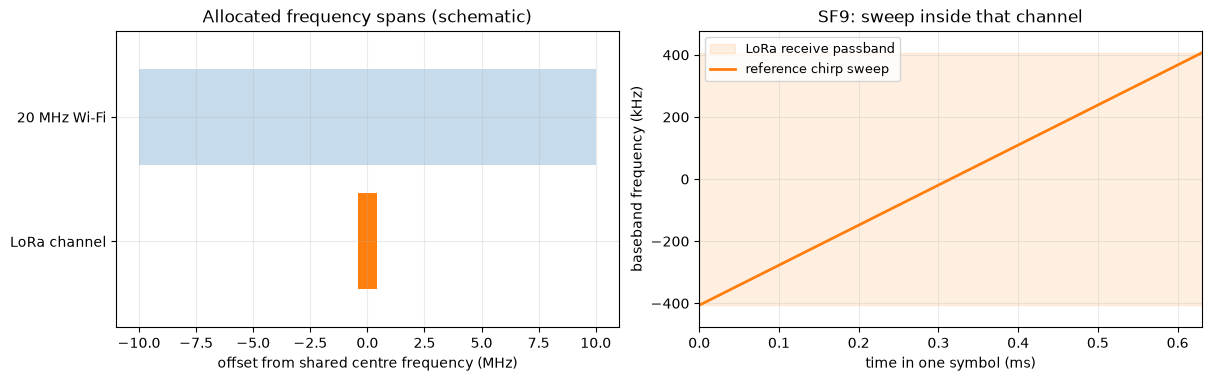

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.7), constrained_layout=True)
axes[0].broken_barh([(-10, 20)], (0.65, 0.5), facecolors='C0', alpha=0.25)
axes[0].broken_barh([(-BW_HZ / 2e6, BW_HZ / 1e6)], (0, 0.5), facecolors='C1')
axes[0].set(xlim=(-11, 11), ylim=(-0.2, 1.35), yticks=(0.25, 0.9), yticklabels=('LoRa channel', '20 MHz Wi-Fi'), xlabel='offset from shared centre frequency (MHz)', title='Allocated frequency spans (schematic)')
duration_ms = (1 << DESIRED_SF) / BW_HZ * 1e3
axes[1].axhspan(-BW_HZ / 2e3, BW_HZ / 2e3, alpha=0.12, color='C1', label='LoRa receive passband')
axes[1].plot([0, duration_ms], [-BW_HZ / 2e3, BW_HZ / 2e3], lw=2, color='C1', label='reference chirp sweep')
axes[1].set(xlim=(0, duration_ms), ylim=(-BW_HZ / 1.7e3, BW_HZ / 1.7e3), xlabel='time in one symbol (ms)', ylabel='baseband frequency (kHz)', title=f'SF{DESIRED_SF}: sweep inside that channel')
axes[1].legend(fontsize=9)
plt.show()

## 5. Motor/ESC receiver desensitization

Ray tracing cannot predict emissions conducted through UAV wiring or radiated by motors, ESCs, regulators, processors, and cables. A defensible first model is a measured motor-on sensitivity penalty $D$ dB. Represent it as an equivalent increase in receiver noise floor:

$$N_{off}=-174+10\log_{10}(BW)+NF,$$

$$N_{on}=N_{off}+D.$$

The 6 dB value below is illustrative. Replace it with repeated motor-off, avionics-on, and hover measurements from the actual installation.


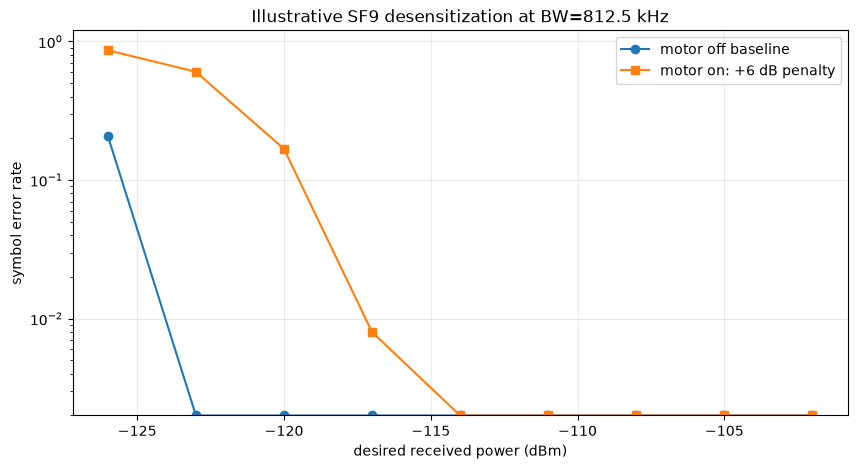

Motor-off thermal noise estimate: -108.9 dBm
Illustrative motor-on equivalent floor: -102.9 dBm


In [8]:
NOISE_FIGURE_DB = 6.0
ILLUSTRATIVE_DESENSE_DB = 6.0
RECEIVED_POWER_DBM = np.arange(-126.0, -101.0, 3.0)
noise_floor_off_dbm = -174 + 10 * np.log10(BW_HZ) + NOISE_FIGURE_DB

def simulate_awgn_ser(sf, snr_db, trials, rng):
    m = 1 << sf
    errors = 0
    for _ in range(trials):
        sent = int(rng.integers(m))
        received = add_awgn(lora_symbol(sent, sf), snr_db, rng)
        detected, _ = detect_symbol(received, sf)
        errors += detected != sent
    return errors / trials

desense_results = {}
for desense_db in (0.0, ILLUSTRATIVE_DESENSE_DB):
    rng = np.random.default_rng(400 + int(desense_db))
    effective_floor_dbm = noise_floor_off_dbm + desense_db
    desense_results[desense_db] = np.array([
        simulate_awgn_ser(DESIRED_SF, received_dbm - effective_floor_dbm, 250, rng)
        for received_dbm in RECEIVED_POWER_DBM
    ])

fig, ax = plt.subplots(figsize=(10, 5))
floor = 1 / 500
ax.semilogy(RECEIVED_POWER_DBM, np.maximum(desense_results[0.0], floor), marker="o", label="motor off baseline")
ax.semilogy(RECEIVED_POWER_DBM, np.maximum(desense_results[ILLUSTRATIVE_DESENSE_DB], floor), marker="s", label=f"motor on: +{ILLUSTRATIVE_DESENSE_DB:g} dB penalty")
ax.set(title=f"Illustrative SF{DESIRED_SF} desensitization at BW={BW_HZ / 1e3:.1f} kHz", xlabel="desired received power (dBm)", ylabel="symbol error rate", ylim=(floor, 1.2))
ax.legend()
plt.show()

print(f"Motor-off thermal noise estimate: {noise_floor_off_dbm:.1f} dBm")
print(f"Illustrative motor-on equivalent floor: {noise_floor_off_dbm + ILLUSTRATIVE_DESENSE_DB:.1f} dBm")


## 6. Combine powers in linear units

Noise and independent interferers add as powers, not by directly adding dBm numbers. For disturbance components $P_k$ in dBm,

$$P_{I+N}=10\log_{10}\left(\sum_k 10^{P_k/10}\right), \qquad SINR=P_s-P_{I+N}.$$

The ledger below illustrates how measured values would be combined before selecting a point on a link-level error curve.


In [9]:
def dbm_to_mw(power_dbm):
    return 10 ** (np.asarray(power_dbm) / 10)

def sum_dbm(power_values_dbm):
    return 10 * np.log10(np.sum(dbm_to_mw(power_values_dbm)))

desired_power_dbm = -116.0
disturbance_dbm = {
    "motor-on equivalent noise": noise_floor_off_dbm + ILLUSTRATIVE_DESENSE_DB,
    "residual external LoRa": -121.0,
    "residual Wi-Fi leakage": -118.0,
}
total_disturbance_dbm = sum_dbm(list(disturbance_dbm.values()))
sinr_db = desired_power_dbm - total_disturbance_dbm

for name, power_dbm in disturbance_dbm.items():
    print(f"{name:30s}: {power_dbm:6.1f} dBm")
print(f"{'total interference + noise':30s}: {total_disturbance_dbm:6.1f} dBm")
print(f"{'desired signal':30s}: {desired_power_dbm:6.1f} dBm")
print(f"{'resulting SINR':30s}: {sinr_db:6.1f} dB")

assert total_disturbance_dbm > max(disturbance_dbm.values())


motor-on equivalent noise     : -102.9 dBm
residual external LoRa        : -121.0 dBm
residual Wi-Fi leakage        : -118.0 dBm
total interference + noise    : -102.7 dBm
desired signal                : -116.0 dBm
resulting SINR                :  -13.3 dB


## 7. Where Sionna RT and measurements belong

Sionna RT can calculate the propagation path from each external transmitter to the UAV. Those path coefficients can scale and delay explicit LoRa or Wi-Fi waveforms before they enter this notebook's receiver model.

Sionna RT does not know the UAV's internal emission spectrum, receiver selectivity, oscillator calibration, automatic-gain-control behavior, or overload point. Supply those from data sheets and conducted/radiated measurements. Keep three quantities separate in the dataset:

- desired received signal power;
- in-band residual interference power after receiver filtering; and
- motor-on sensitivity or noise-floor change.


## Takeaways

- A co-SF collision produces a competing decision-bin peak; capture therefore depends strongly on relative received power and timing.
- Cross-SF interference is spread by the wrong dechirp reference, but it is not perfectly harmless.
- Residual frequency offset is measured in fractions of the LoRa FFT-bin spacing; the same hertz error occupies more bins at higher SF.
- Wi-Fi must be filtered into the LoRa receiver bandwidth before comparing powers. The surrogate here models only that residual, not a complete 802.11 packet.
- Motor/ESC desensitization should come from the actual UAV installation. Model it as a measured sensitivity/noise penalty unless its spectrum and coupling path are known.
- Notebook 7 can combine the channel from Notebooks 4-5, these receiver impairments, and the packet/FEC logic from Notebook 1 to estimate PER and choose SF, bandwidth, coding rate, and transmit power.


## Focused references

- O. Afisiadis et al., [On the Error Rate of the LoRa Modulation with Interference](https://arxiv.org/abs/1905.11252): waveform-level interference and detection analysis.
- A. Waret et al., [LoRa Throughput Analysis with Imperfect Spreading Factor Orthogonality](https://arxiv.org/abs/1803.06534): why different SFs do not guarantee independent, collision-free links.

**UAV connection:** measure motor-off versus motor-on noise and packet delivery at the installed antenna. A high-link-budget radio still fails if onboard interference consumes its margin.